# Irrigation Need — Notebook 2: Cleaning & Rebalancing
**Kaggle Playground S6E4**

Inputs: `Data/train.csv`, `Data/test.csv`  
Outputs:
- `Data/processed/train_unscaled.parquet` — for tree models
- `Data/processed/train_scaled.parquet` — for linear/distance models
- `Data/processed/test_unscaled.parquet`
- `Data/processed/test_scaled.parquet`
- `Data/processed/scaler.pkl` — fitted scaler object

Key decisions from EDA:
- No missing values
- No IQR outliers but Rainfall_mm has a suspicious near-zero cluster to flag
- Severe class imbalance: High = 3.3% (17.61x ratio)
- Distributions are mostly uniform → scaler choice will be data-driven
- Formula BA = 0.961 → formula features are the core signal
- Non-formula categoricals (Season, Region, etc.) have near-zero predictive power


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

PALETTE = {'Low': '#02C39A', 'Medium': '#F4A261', 'High': '#E63946'}
SEED = 42
os.makedirs('../Data/processed', exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
train = pd.read_csv('../Data/train.csv', index_col='id')
test  = pd.read_csv('../Data/test.csv',  index_col='id')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')
print(f'\nTrain index: {train.index.name}, range [{train.index.min()}, {train.index.max()}]')
print(f'Test  index: {test.index.name},  range [{test.index.min()},  {test.index.max()}]')
train.head(3)

Train: (630000, 20)
Test:  (270000, 19)

Train index: id, range [0, 629999]
Test  index: id,  range [630000,  899999]


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
id,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.920,32.580,1.010,3.050,15.010,50.610,725.990,5.900,16.790,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.820,No,112.160,East,Low
1,Clay,7.080,56.610,0.440,2.000,22.920,67.860,985.660,6.980,3.390,Wheat,Vegetative,Kharif,Rainfed,River,5.270,Yes,47.160,South,Low
2,Clay,5.690,27.710,0.810,2.830,26.970,92.220,2201.700,6.050,3.850,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.240,Yes,110.380,North,Low


## 2. Separate Target

In [3]:
y = train['Irrigation_Need'].copy()
train = train.drop(columns=['Irrigation_Need'])

print('Target separated.')
print(y.value_counts())

Target separated.
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


## 3. Rainfall_mm Near-Zero Investigation

Rainfall_mm near-zero cluster:
  <    1mm :      1 rows (0.00%)
  <    5mm :    175 rows (0.03%)
  <   10mm :  1,725 rows (0.27%)
  <   50mm :  4,939 rows (0.78%)
  <  100mm :  6,311 rows (1.00%)

Class distribution for Rainfall_mm < 10mm:
Irrigation_Need
Medium    1059
High       478
Low        188
Name: count, dtype: int64
Irrigation_Need
Medium   61.400
High     27.700
Low      10.900
Name: proportion, dtype: float64

Class distribution overall:
Irrigation_Need
Low      58.700
Medium   37.900
High      3.300
Name: proportion, dtype: float64


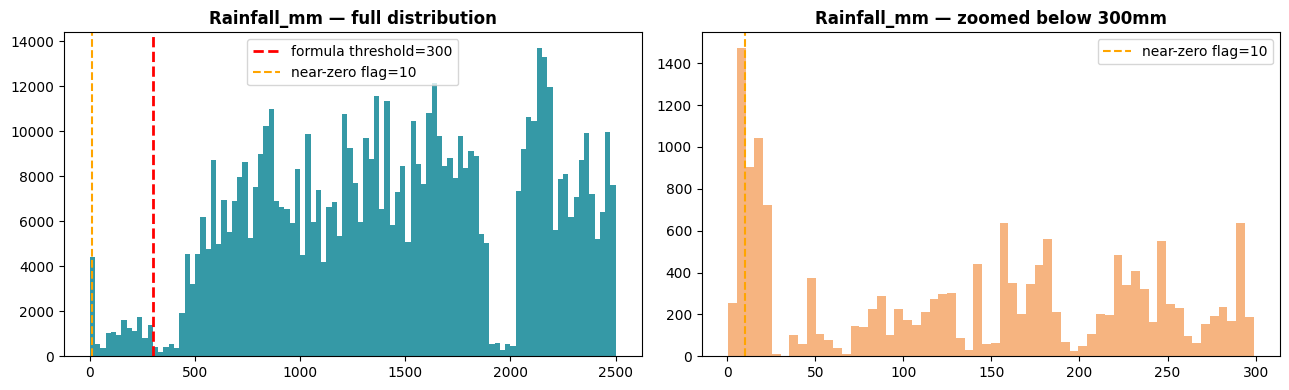

In [6]:
# Flag rows where Rainfall_mm is suspiciously low
thresholds = [1, 5, 10, 50, 100]
print('Rainfall_mm near-zero cluster:')
for t in thresholds:
    n = (train['Rainfall_mm'] < t).sum()
    print(f'  < {t:4d}mm : {n:6,} rows ({n/len(train)*100:.2f}%)')

# What class do these rows belong to?
print('\nClass distribution for Rainfall_mm < 10mm:')
mask_low_rain = train['Rainfall_mm'] < 10
print(y[mask_low_rain].value_counts())
print(y[mask_low_rain].value_counts(normalize=True).mul(100).round(1))

print('\nClass distribution overall:')
print(y.value_counts(normalize=True).mul(100).round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['Rainfall_mm'], bins=100, color='#028090', alpha=0.8)
axes[0].axvline(300, color='red', linestyle='--', linewidth=2, label='formula threshold=300')
axes[0].axvline(10, color='orange', linestyle='--', linewidth=1.5, label='near-zero flag=10')
axes[0].set_title('Rainfall_mm — full distribution', fontweight='bold')
axes[0].legend()

axes[1].hist(train[train['Rainfall_mm'] < 300]['Rainfall_mm'], 
             bins=60, color='#F4A261', alpha=0.8)
axes[1].axvline(10, color='orange', linestyle='--', linewidth=1.5, label='near-zero flag=10')
axes[1].set_title('Rainfall_mm — zoomed below 300mm', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()



DECISION: Retain near-zero Rainfall_mm rows.
- They correctly map to High irrigation need (dry conditions).
- Removing them would delete legitimate High class examples,
  worsening the already severe imbalance.
- No imputation needed — values are plausible for arid regions.

## 4. Distribution Shape Analysis — Choosing the Right Scaler

In [7]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()
print(f'Numeric features: {num_cols}')

# Skewness and kurtosis
shape_df = pd.DataFrame({
    'skewness': train[num_cols].skew(),
    'kurtosis': train[num_cols].kurt(),
    'min':      train[num_cols].min(),
    'max':      train[num_cols].max(),
    'mean':     train[num_cols].mean(),
    'std':      train[num_cols].std(),
}).round(3)

# Classify distribution shape
def classify_dist(skew, kurt):
    if abs(skew) < 0.5 and abs(kurt) < 1:
        return 'uniform/flat'
    elif abs(skew) < 0.5:
        return 'near-normal'
    elif abs(skew) >= 1:
        return 'skewed'
    else:
        return 'moderate skew'

shape_df['shape'] = shape_df.apply(lambda r: classify_dist(r['skewness'], r['kurtosis']), axis=1)

# Scaler recommendation per feature
def recommend_scaler(row):
    if row['shape'] == 'skewed':
        return 'RobustScaler'
    elif row['shape'] in ['uniform/flat', 'moderate skew']:
        return 'MinMaxScaler'
    else:
        return 'StandardScaler'

shape_df['recommended_scaler'] = shape_df.apply(recommend_scaler, axis=1)

print('\n=== Distribution Shape & Scaler Recommendation ===')
print(shape_df[['skewness', 'kurtosis', 'shape', 'recommended_scaler']].to_string())

# Summary
print('\nScaler vote count:')
print(shape_df['recommended_scaler'].value_counts())

Numeric features: ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

=== Distribution Shape & Scaler Recommendation ===
                         skewness  kurtosis         shape recommended_scaler
Soil_pH                     0.070    -1.145   near-normal     StandardScaler
Soil_Moisture              -0.064    -1.181   near-normal     StandardScaler
Organic_Carbon              0.105    -1.166   near-normal     StandardScaler
Electrical_Conductivity     0.048    -1.148   near-normal     StandardScaler
Temperature_C              -0.004    -1.206   near-normal     StandardScaler
Humidity                   -0.089    -1.164   near-normal     StandardScaler
Rainfall_mm                -0.118    -0.940  uniform/flat       MinMaxScaler
Sunlight_Hours             -0.035    -1.206   near-normal     StandardScaler
Wind_Speed_kmh             -0.028  

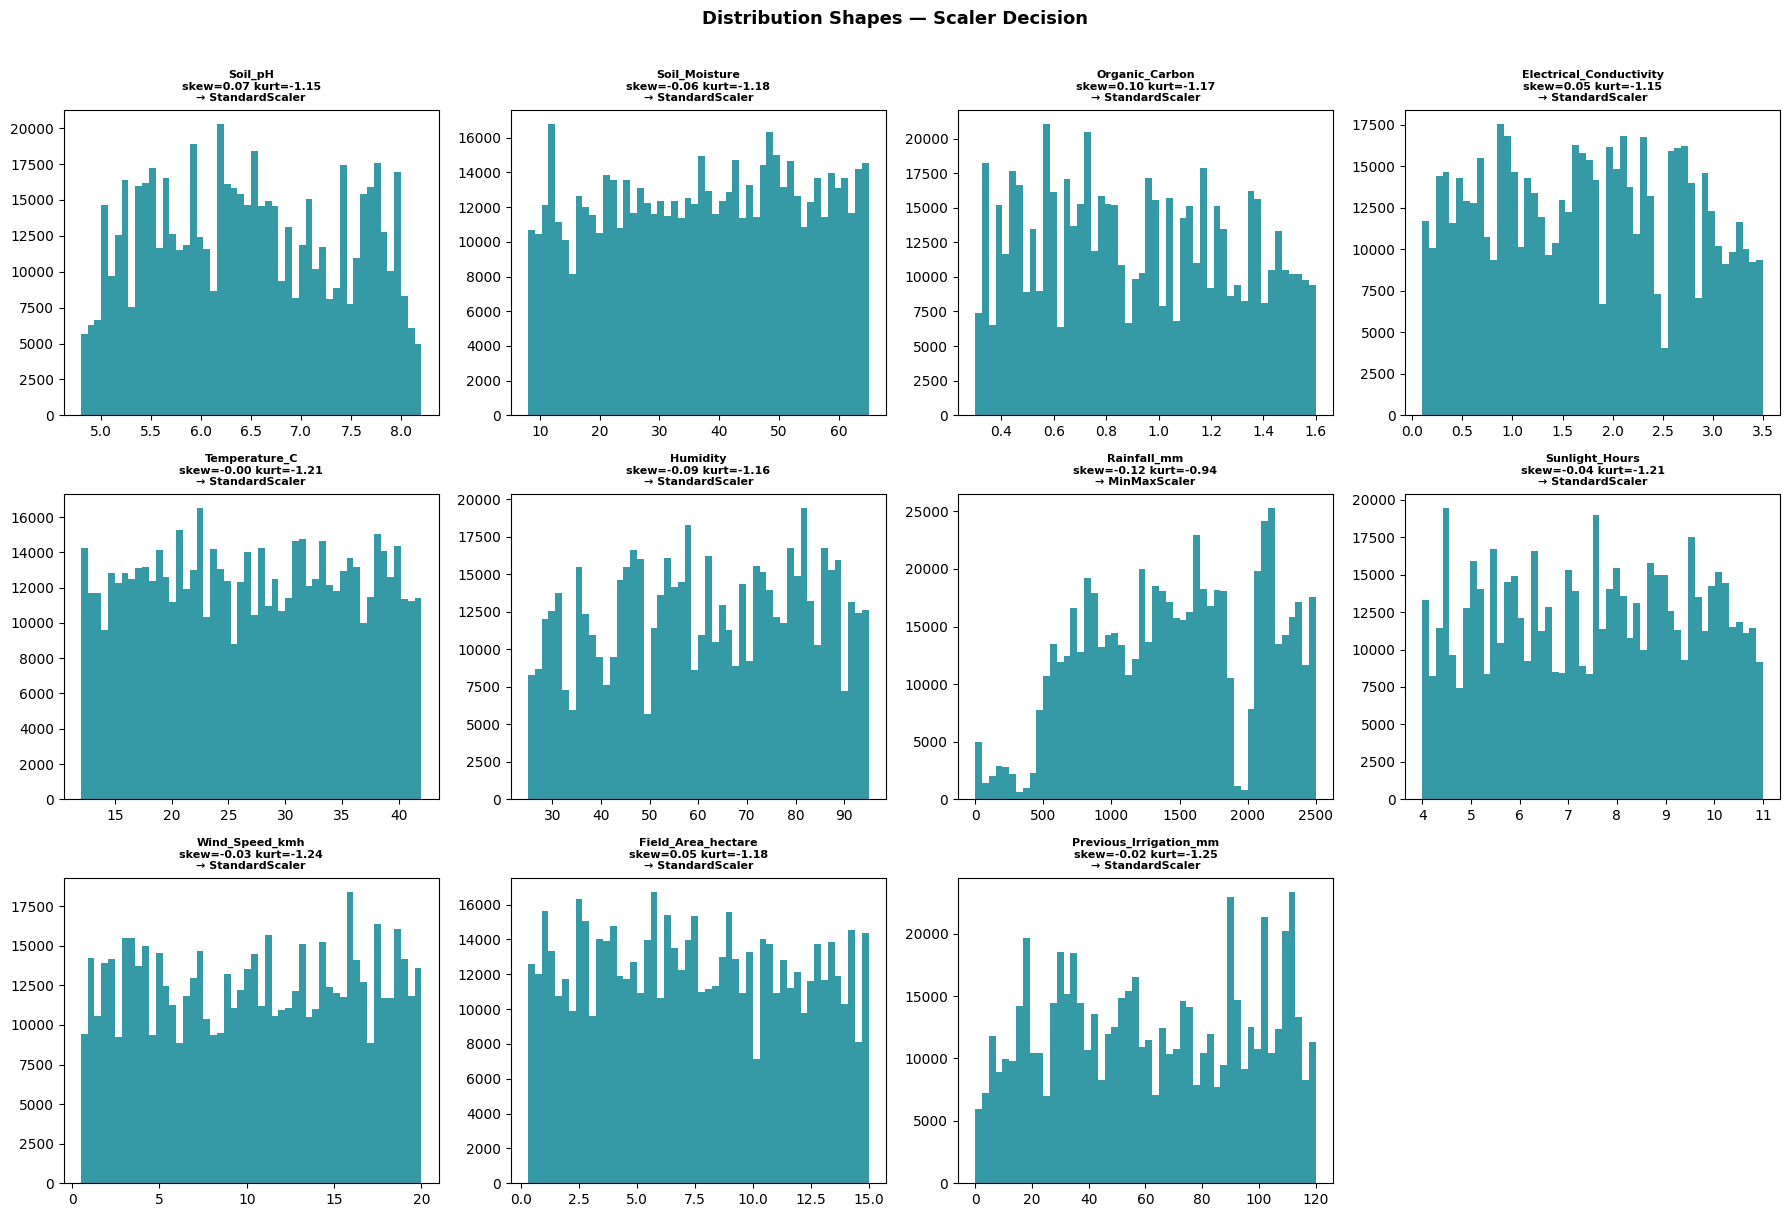


Final decision: StandardScaler (majority vote across features)


In [9]:
# Visual: histograms with skewness annotation
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(train[col], bins=50, color='#028090', alpha=0.8, edgecolor='none')
    skew = shape_df.loc[col, 'skewness']
    kurt = shape_df.loc[col, 'kurtosis']
    shape = shape_df.loc[col, 'shape']
    scaler = shape_df.loc[col, 'recommended_scaler']
    ax.set_title(f'{col}\nskew={skew:.2f} kurt={kurt:.2f}\n→ {scaler}', 
                 fontsize=8, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution Shapes — Scaler Decision', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Final scaler decision
majority = shape_df['recommended_scaler'].value_counts().idxmax()
print(f'\nFinal decision: {majority} (majority vote across features)')

## 5. Categorical Encoding

In [10]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')

# Cardinality check
for col in cat_cols:
    vals = sorted(train[col].unique())
    print(f'  {col:25s}: {len(vals)} values → {vals}')

Categorical columns: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
  Soil_Type                : 4 values → ['Clay', 'Loamy', 'Sandy', 'Silt']
  Crop_Type                : 6 values → ['Cotton', 'Maize', 'Potato', 'Rice', 'Sugarcane', 'Wheat']
  Crop_Growth_Stage        : 4 values → ['Flowering', 'Harvest', 'Sowing', 'Vegetative']
  Season                   : 3 values → ['Kharif', 'Rabi', 'Zaid']
  Irrigation_Type          : 4 values → ['Canal', 'Drip', 'Rainfed', 'Sprinkler']
  Water_Source             : 4 values → ['Groundwater', 'Rainwater', 'Reservoir', 'River']
  Mulching_Used            : 2 values → ['No', 'Yes']
  Region                   : 5 values → ['Central', 'East', 'North', 'South', 'West']


In [11]:
# Strategy:
# - Binary (Mulching_Used): map directly to 0/1
# - Low cardinality (Crop_Growth_Stage, Season, Soil_Type, etc.): Label Encode
#   Tree models handle ordinal encoding fine. 
#   We keep the mapping dict for interpretability.

label_encoders = {}
encoding_maps  = {}

for col in cat_cols:
    le = LabelEncoder()
    # Fit on train + test combined to avoid unseen label issues
    combined = pd.concat([train[col], test[col]], axis=0)
    le.fit(combined)
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    label_encoders[col] = le
    encoding_maps[col]  = dict(zip(le.classes_, le.transform(le.classes_)))

print('Encoding maps:')
for col, mapping in encoding_maps.items():
    print(f'  {col}: {mapping}')

# Save encoders
with open('../Data/processed/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print('\nLabel encoders saved.')

Encoding maps:
  Soil_Type: {'Clay': 0, 'Loamy': 1, 'Sandy': 2, 'Silt': 3}
  Crop_Type: {'Cotton': 0, 'Maize': 1, 'Potato': 2, 'Rice': 3, 'Sugarcane': 4, 'Wheat': 5}
  Crop_Growth_Stage: {'Flowering': 0, 'Harvest': 1, 'Sowing': 2, 'Vegetative': 3}
  Season: {'Kharif': 0, 'Rabi': 1, 'Zaid': 2}
  Irrigation_Type: {'Canal': 0, 'Drip': 1, 'Rainfed': 2, 'Sprinkler': 3}
  Water_Source: {'Groundwater': 0, 'Rainwater': 1, 'Reservoir': 2, 'River': 3}
  Mulching_Used: {'No': 0, 'Yes': 1}
  Region: {'Central': 0, 'East': 1, 'North': 2, 'South': 3, 'West': 4}

Label encoders saved.


## 6. Formula Feature Engineering

In [12]:
def add_formula_features(df, encoding_maps):
    d = df.copy()

    # Binary threshold features (on raw numeric values)
    d['soil_lt_25']  = (d['Soil_Moisture'] < 25).astype(int)
    d['temp_gt_30']  = (d['Temperature_C'] > 30).astype(int)
    d['rain_lt_300'] = (d['Rainfall_mm'] < 300).astype(int)
    d['wind_gt_10']  = (d['Wind_Speed_kmh'] > 10).astype(int)

    # Crop Growth Stage dummies (using encoding map)
    cgs_map = encoding_maps['Crop_Growth_Stage']
    d['CGS_Flowering']  = (d['Crop_Growth_Stage'] == cgs_map['Flowering']).astype(int)
    d['CGS_Harvest']    = (d['Crop_Growth_Stage'] == cgs_map['Harvest']).astype(int)
    d['CGS_Sowing']     = (d['Crop_Growth_Stage'] == cgs_map['Sowing']).astype(int)
    d['CGS_Vegetative'] = (d['Crop_Growth_Stage'] == cgs_map['Vegetative']).astype(int)

    # Mulching dummies
    mulch_map = encoding_maps['Mulching_Used']
    d['mulch_no']  = (d['Mulching_Used'] == mulch_map['No']).astype(int)
    d['mulch_yes'] = (d['Mulching_Used'] == mulch_map['Yes']).astype(int)

    # Logit scores
    d['logit_low'] = (
        16.3173
        + (-11.0237 * d['soil_lt_25'])
        + (-5.8559  * d['temp_gt_30'])
        + (-10.8500 * d['rain_lt_300'])
        + (-5.8284  * d['wind_gt_10'])
        + (-5.4155  * d['CGS_Flowering'])
        + (5.5073   * d['CGS_Harvest'])
        + (5.2299   * d['CGS_Sowing'])
        + (-5.4617  * d['CGS_Vegetative'])
        + (-3.0014  * d['mulch_no'])
        + (2.8613   * d['mulch_yes'])
    )
    d['logit_medium'] = (
        4.6524
        + (0.3290  * d['soil_lt_25'])
        + (-0.0204 * d['temp_gt_30'])
        + (0.1542  * d['rain_lt_300'])
        + (0.0841  * d['wind_gt_10'])
        + (0.3586  * d['CGS_Flowering'])
        + (-0.1348 * d['CGS_Harvest'])
        + (-0.3547 * d['CGS_Sowing'])
        + (0.3334  * d['CGS_Vegetative'])
        + (0.1883  * d['mulch_no'])
        + (0.0142  * d['mulch_yes'])
    )
    d['logit_high'] = (
        -20.9697
        + (10.6947 * d['soil_lt_25'])
        + (5.8763  * d['temp_gt_30'])
        + (10.6958 * d['rain_lt_300'])
        + (5.7444  * d['wind_gt_10'])
        + (5.0569  * d['CGS_Flowering'])
        + (-5.3725 * d['CGS_Harvest'])
        + (-4.8752 * d['CGS_Sowing'])
        + (5.1283  * d['CGS_Vegetative'])
        + (2.8131  * d['mulch_no'])
        + (-2.8755 * d['mulch_yes'])
    )

    # Softmax probabilities
    logits = d[['logit_low', 'logit_medium', 'logit_high']].values
    exp_l  = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs  = exp_l / exp_l.sum(axis=1, keepdims=True)
    d['prob_low']    = probs[:, 0]
    d['prob_medium'] = probs[:, 1]
    d['prob_high']   = probs[:, 2]

    # Integer rule score
    high_score = (2*d['soil_lt_25'] + 2*d['rain_lt_300']
                  + d['temp_gt_30'] + d['wind_gt_10'])
    low_score  = 2*d['CGS_Harvest'] + 2*d['CGS_Sowing'] + d['mulch_yes']
    d['rule_score'] = high_score - low_score

    # Margin between top two logits (confidence proxy)
    sorted_logits = np.sort(logits, axis=1)
    d['logit_margin'] = sorted_logits[:, 2] - sorted_logits[:, 1]

    return d


train = add_formula_features(train, encoding_maps)
test  = add_formula_features(test,  encoding_maps)

formula_cols = [
    'soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10',
    'CGS_Flowering', 'CGS_Harvest', 'CGS_Sowing', 'CGS_Vegetative',
    'mulch_no', 'mulch_yes',
    'logit_low', 'logit_medium', 'logit_high',
    'prob_low', 'prob_medium', 'prob_high',
    'rule_score', 'logit_margin'
]
print(f'Formula features added: {len(formula_cols)}')
print(f'Total train columns: {train.shape[1]}')
train[formula_cols].describe()

Formula features added: 18
Total train columns: 37


,soil_lt_25,temp_gt_30,rain_lt_300,wind_gt_10,CGS_Flowering,CGS_Harvest,CGS_Sowing,CGS_Vegetative,mulch_no,mulch_yes,logit_low,logit_medium,logit_high,prob_low,prob_medium,prob_high,rule_score,logit_margin
count,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000
mean,0.281,0.405,0.026,0.527,0.250,0.266,0.234,0.250,0.502,0.498,7.384,4.941,-12.325,0.591,0.369,0.040,0.048,7.559
std,0.450,0.491,0.159,0.499,0.433,0.442,0.423,0.433,0.500,0.500,10.132,0.378,9.803,0.474,0.456,0.177,1.822,5.174
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-25.704,4.291,-29.218,0.000,0.000,0.000,-3.000,0.568
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.971,4.595,-18.788,0.039,0.000,0.000,-1.000,3.004
50%,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,7.888,5.000,-12.973,0.943,0.056,0.000,0.000,7.515
75%,1.000,1.000,0.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,13.763,5.258,-6.958,1.000,0.956,0.000,1.000,8.801
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,24.686,5.767,19.983,1.000,0.999,1.000,6.000,20.154


## 7. Encode Target

In [13]:
target_order = ['Low', 'Medium', 'High']
target_map   = {'Low': 0, 'Medium': 1, 'High': 2}
target_inv   = {0: 'Low', 1: 'Medium', 2: 'High'}

y_encoded = y.map(target_map)

print('Target encoding:')
print(target_map)
print(f'\ny_encoded value counts:')
print(y_encoded.value_counts().sort_index())

# Save target mapping
with open('../Data/processed/target_map.pkl', 'wb') as f:
    pickle.dump({'map': target_map, 'inv': target_inv}, f)
print('\nTarget mapping saved.')

Target encoding:
{'Low': 0, 'Medium': 1, 'High': 2}

y_encoded value counts:
Irrigation_Need
0    369917
1    239074
2     21009
Name: count, dtype: int64

Target mapping saved.


## 8. Class Imbalance — Strategy

In [15]:
# Class weights — to pass directly to models
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=y_encoded)
class_weight_dict = dict(zip(classes, weights))

print('=== Class Weights (balanced) ===')
for cls, w in class_weight_dict.items():
    label = target_inv[cls]
    count = (y_encoded == cls).sum()
    print(f'  {label:8s} (class {cls}): weight = {w:.4f}  |  count = {count:,}')

print(f'\nHigh class weight is {class_weight_dict[2]:.1f}x Low class weight')

# Sample weights array (for LGBM/XGB)
sample_weights = y_encoded.map(class_weight_dict).values
print(f'\nSample weights — shape: {sample_weights.shape}, unique: {np.unique(sample_weights).round(3)}')

# Save
with open('../Data/processed/class_weights.pkl', 'wb') as f:
    pickle.dump({'class_weight_dict': class_weight_dict,
                 'sample_weights': sample_weights}, f)

=== Class Weights (balanced) ===
  Low      (class 0): weight = 0.5677  |  count = 369,917
  Medium   (class 1): weight = 0.8784  |  count = 239,074
  High     (class 2): weight = 9.9957  |  count = 21,009

High class weight is 10.0x Low class weight

Sample weights — shape: (630000,), unique: [0.568 0.878 9.996]


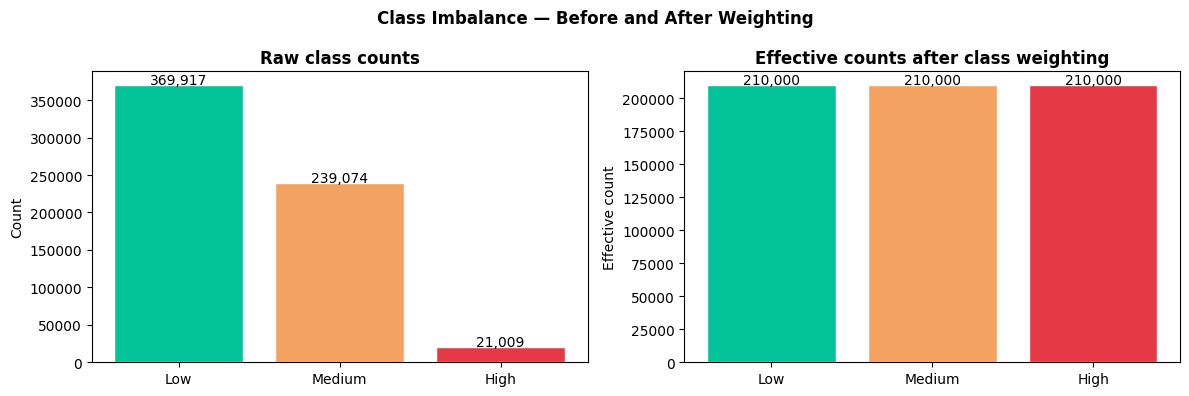

In [16]:
# Visualise imbalance and weight effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = [y_encoded.eq(c).sum() for c in [0, 1, 2]]
labels = ['Low', 'Medium', 'High']
colors = [PALETTE[l] for l in labels]

axes[0].bar(labels, counts, color=colors, edgecolor='white')
axes[0].set_title('Raw class counts', fontweight='bold')
axes[0].set_ylabel('Count')
for i, c in enumerate(counts):
    axes[0].text(i, c + 1000, f'{c:,}', ha='center', fontsize=10)

eff_counts = [c * class_weight_dict[i] for i, c in enumerate(counts)]
axes[1].bar(labels, eff_counts, color=colors, edgecolor='white')
axes[1].set_title('Effective counts after class weighting', fontweight='bold')
axes[1].set_ylabel('Effective count')
for i, c in enumerate(eff_counts):
    axes[1].text(i, c + 1000, f'{c:,.0f}', ha='center', fontsize=10)

plt.suptitle('Class Imbalance — Before and After Weighting', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Scaling — Apply Chosen Scaler

In [18]:
raw_num_cols = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'
]

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

standard_cols = [c for c in raw_num_cols if c != 'Rainfall_mm']
minmax_cols   = ['Rainfall_mm']

preprocessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), standard_cols),
    ('minmax',   MinMaxScaler(),   minmax_cols),
], remainder='passthrough')

train_scaled = train.copy()
test_scaled  = test.copy()

train_arr = preprocessor.fit_transform(train[raw_num_cols])
test_arr  = preprocessor.transform(test[raw_num_cols])

train_scaled[raw_num_cols] = train_arr
test_scaled[raw_num_cols]  = test_arr

# Save the ColumnTransformer instead of single scaler
with open('../Data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

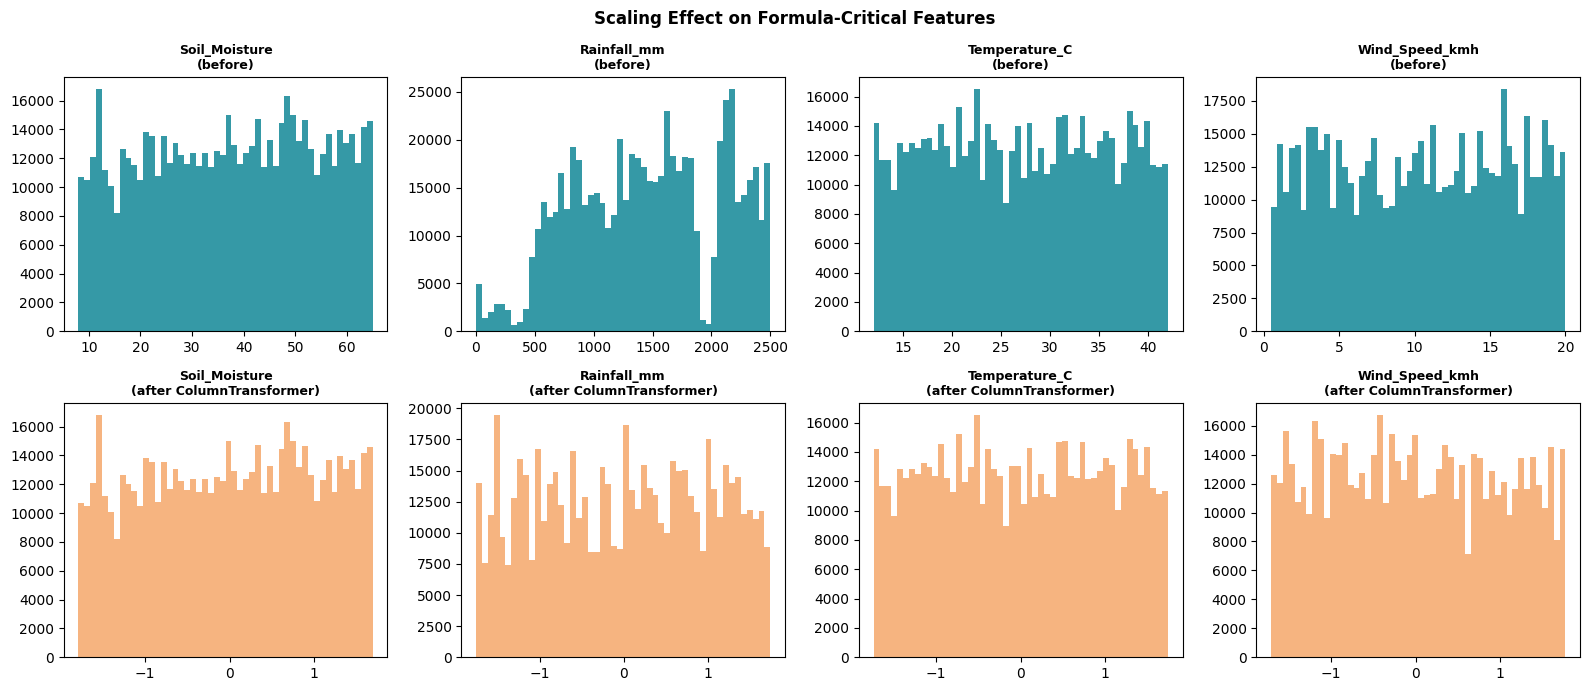

In [21]:
# Visual check: before vs after scaling for formula-critical features
check_cols = ['Soil_Moisture', 'Rainfall_mm', 'Temperature_C', 'Wind_Speed_kmh']

fig, axes = plt.subplots(2, len(check_cols), figsize=(16, 7))

for j, col in enumerate(check_cols):
    axes[0, j].hist(train[col], bins=50, color='#028090', alpha=0.8)
    axes[0, j].set_title(f'{col}\n(before)', fontweight='bold', fontsize=9)

    axes[1, j].hist(train_scaled[col], bins=50, color='#F4A261', alpha=0.8)
    axes[1, j].set_title(f'{col}\n(after ColumnTransformer)', fontweight='bold', fontsize=9)

plt.suptitle('Scaling Effect on Formula-Critical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Final Feature Set Summary

In [22]:
all_features = train.columns.tolist()

original_raw = [
    'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
    'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
    'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
    'Mulching_Used', 'Previous_Irrigation_mm', 'Region'
]
formula_features = formula_cols

print(f'Total features: {len(all_features)}')
print(f'  Original (encoded): {len(original_raw)}')
print(f'  Formula-derived:    {len(formula_features)}')
print(f'\nAll features:')
for f in all_features:
    tag = '★ formula' if f in formula_features else '  original'
    print(f'  {tag} | {f}')

Total features: 37
  Original (encoded): 19
  Formula-derived:    18

All features:
    original | Soil_Type
    original | Soil_pH
    original | Soil_Moisture
    original | Organic_Carbon
    original | Electrical_Conductivity
    original | Temperature_C
    original | Humidity
    original | Rainfall_mm
    original | Sunlight_Hours
    original | Wind_Speed_kmh
    original | Crop_Type
    original | Crop_Growth_Stage
    original | Season
    original | Irrigation_Type
    original | Water_Source
    original | Field_Area_hectare
    original | Mulching_Used
    original | Previous_Irrigation_mm
    original | Region
  ★ formula | soil_lt_25
  ★ formula | temp_gt_30
  ★ formula | rain_lt_300
  ★ formula | wind_gt_10
  ★ formula | CGS_Flowering
  ★ formula | CGS_Harvest
  ★ formula | CGS_Sowing
  ★ formula | CGS_Vegetative
  ★ formula | mulch_no
  ★ formula | mulch_yes
  ★ formula | logit_low
  ★ formula | logit_medium
  ★ formula | logit_high
  ★ formula | prob_low
  ★ formula |

## 11. Save Processed Data

In [24]:
# Add target back to train for saving
train_unscaled_out = train.copy()
train_unscaled_out['Irrigation_Need'] = y_encoded.values

train_scaled_out = train_scaled.copy()
train_scaled_out['Irrigation_Need'] = y_encoded.values

# Save
train_unscaled_out.to_parquet('../Data/processed/train_unscaled.parquet')
train_scaled_out.to_parquet('../Data/processed/train_scaled.parquet')
test.to_parquet('../Data/processed/test_unscaled.parquet')
test_scaled.to_parquet('../Data/processed/test_scaled.parquet')

# Also save sample weights aligned with train index
sw_df = pd.DataFrame({'sample_weight': sample_weights}, index=train.index)
sw_df.to_parquet('../Data/processed/sample_weights.parquet')

print('=== Saved to Data/processed/ ===')
for f in sorted(os.listdir('../Data/processed/')):
    size = os.path.getsize(f'../Data/processed/{f}') / 1e6
    print(f'  {f:45s} {size:.1f} MB')

print(f'\nFinal shapes:')
print(f'  train_unscaled: {train_unscaled_out.shape}')
print(f'  train_scaled:   {train_scaled_out.shape}')
print(f'  test_unscaled:  {test.shape}')
print(f'  test_scaled:    {test_scaled.shape}')

=== Saved to Data/processed/ ===
  class_weights.pkl                             5.0 MB
  label_encoders.pkl                            0.0 MB
  sample_weights.parquet                        3.0 MB
  scaler.pkl                                    0.0 MB
  target_map.pkl                                0.0 MB
  test_scaled.parquet                           8.6 MB
  test_unscaled.parquet                         8.5 MB
  train_scaled.parquet                          19.6 MB
  train_unscaled.parquet                        19.4 MB

Final shapes:
  train_unscaled: (630000, 38)
  train_scaled:   (630000, 38)
  test_unscaled:  (270000, 37)
  test_scaled:    (270000, 37)


## 12. Cleaning Summary

In [27]:
print('=' * 65)
print('CLEANING & REBALANCING SUMMARY')
print('=' * 65)
print(f"""
INDEX
  id set as index (not dropped)

MISSING VALUES
  None — no action needed

RAINFALL_MM NEAR-ZERO ROWS
  Retained — legitimate arid conditions → correct High labels

CATEGORICAL ENCODING
  LabelEncoder applied to all {len(cat_cols)} categoricals
  Fit on train+test combined to avoid unseen label issues
  Mappings saved to label_encoders.pkl

FORMULA FEATURES ADDED ({len(formula_cols)} new columns)
  Binary thresholds, logit scores, softmax probs,
  rule score, logit margin (confidence proxy)

SCALING
  Applied to {len(raw_num_cols)} raw numeric columns only
  Formula-derived features NOT scaled (already bounded)
  Scaler fit on train only → saved to scaler.pkl

CLASS IMBALANCE
  Ratio: 17.61x (High = 3.3%)
  Strategy: class weights computed (balanced)
  High class weight: {class_weight_dict[2]:.2f}x
  Saved to class_weights.pkl + sample_weights.parquet
  → Pass to models directly, no data augmentation

OUTPUTS
  train_unscaled.parquet  → tree models (LGBM, XGB, CatBoost)
  train_scaled.parquet    → linear/distance models
  test_unscaled.parquet
  test_scaled.parquet
  scaler.pkl
  label_encoders.pkl
  target_map.pkl
  class_weights.pkl
  sample_weights.parquet
""")
print('=' * 65)
print('→ Proceed to 03_Model_LightGBM.ipynb')
print('=' * 65)

CLEANING & REBALANCING SUMMARY

INDEX
  id set as index (not dropped)

MISSING VALUES
  None — no action needed

RAINFALL_MM NEAR-ZERO ROWS
  Retained — legitimate arid conditions → correct High labels

CATEGORICAL ENCODING
  LabelEncoder applied to all 8 categoricals
  Fit on train+test combined to avoid unseen label issues
  Mappings saved to label_encoders.pkl

FORMULA FEATURES ADDED (18 new columns)
  Binary thresholds, logit scores, softmax probs,
  rule score, logit margin (confidence proxy)

SCALING
  Applied to 11 raw numeric columns only
  Formula-derived features NOT scaled (already bounded)
  Scaler fit on train only → saved to scaler.pkl

CLASS IMBALANCE
  Ratio: 17.61x (High = 3.3%)
  Strategy: class weights computed (balanced)
  High class weight: 10.00x
  Saved to class_weights.pkl + sample_weights.parquet
  → Pass to models directly, no data augmentation

OUTPUTS
  train_unscaled.parquet  → tree models (LGBM, XGB, CatBoost)
  train_scaled.parquet    → linear/distance mo